# Evaluating Input Techniques - Results

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")

TECHNIQUES = ["mouse", "mouse+150ms", "touchpad", "pose"]
COLOR = dict(zip(TECHNIQUES, sns.color_palette("Set2", len(TECHNIQUES))))

In [2]:
def load(prefix):
    frames = []
    for f in sorted(glob.glob(os.path.join("data", prefix + "_*.csv"))):
        df = pd.read_csv(f)
        if len(df) < 2:
            print("skipping", os.path.basename(f), "- only", len(df), "row (aborted/empty run)")
        else:
            frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["tech"] = np.where(out.latency_ms > 0,
                           out.technique + "+" + out.latency_ms.astype(str) + "ms",
                           out.technique)
    return out

fitts = load("fitts")
steer = load("steering")
print("Fitts rows:", len(fitts))
print("Steering rows:", len(steer))

skipping fitts_mouse_10_60_400_lat0_1.csv - only 1 row (aborted/empty run)
Fitts rows: 1913
Steering rows: 405


In [3]:
fitts.head()

,iteration,pid,technique,num_targets,target_w,target_d,latency_ms,target_id,step,click_x,click_y,target_x,target_y,success,mt_ms,timestamp,tech
0,1,1,mouse,9,40,400,0,0,0,509.0,610.0,500.0,600.0,1,2534,1782578953232,mouse
1,1,1,mouse,9,40,400,0,5,1,574.0,211.0,568.4,212.1,1,762,1782578953994,mouse
2,1,1,mouse,9,40,400,0,1,2,356.0,548.0,371.4,553.2,1,868,1782578954862,mouse
3,1,1,mouse,9,40,400,0,6,3,681.0,292.0,673.2,300.0,1,954,1782578955816,mouse
4,1,1,mouse,9,40,400,0,2,4,293.0,427.0,303.0,434.7,1,854,1782578956670,mouse


In [4]:
fitts["tech"].value_counts()

tech
pose           659
mouse+150ms    428
mouse          414
touchpad       412
Name: count, dtype: int64

In [5]:
fitts["difficulty"] = np.log2(fitts.target_d / fitts.target_w + 1)  # ID = log2(D/W + 1)
fitts["difficulty_lbl"] = fitts.difficulty.round(2).astype(str)
taps = fitts[(fitts.step > 0) & (fitts.success == 1)].copy()  # remove the first clicks, keep only successful taps
len(taps)

1484

In [6]:
steer["difficulty"] = steer.tunnel_a / steer.tunnel_w  # ID = A/W
steer["difficulty_lbl"] = steer.difficulty.round(2).astype(str)
steer["tech"].value_counts()

tech
pose           116
touchpad       109
mouse+150ms     90
mouse           90
Name: count, dtype: int64

In [7]:
def ci95(values):
    v = np.asarray(values, float)
    v = v[~np.isnan(v)]
    if len(v) < 2:
        return np.nan
    return stats.sem(v) * stats.t.ppf(0.975, len(v) - 1)

# Fitts' Law

## Speed

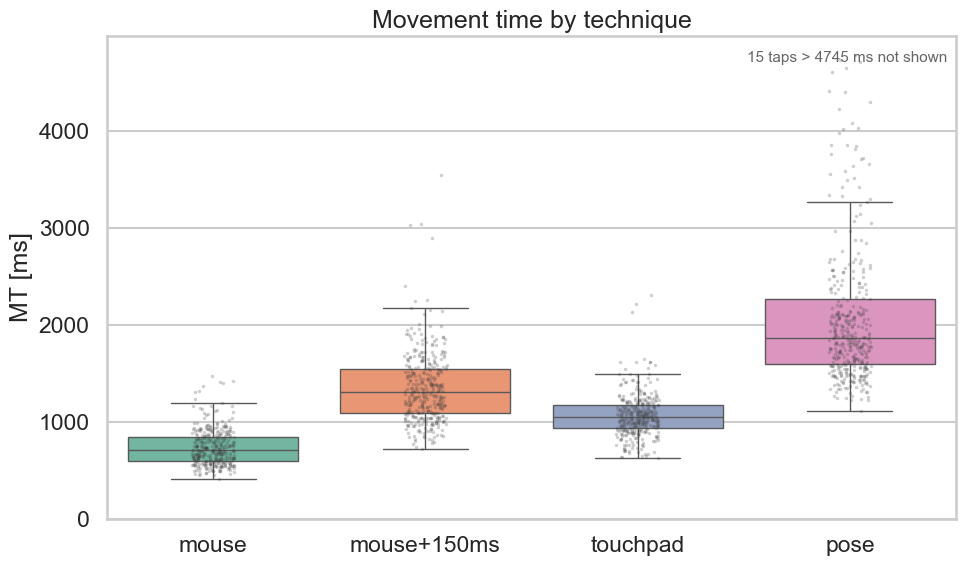

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=taps, x="tech", y="mt_ms", order=TECHNIQUES, hue="tech",
            palette=COLOR, legend=False, showfliers=False, ax=ax)
sns.stripplot(data=taps, x="tech", y="mt_ms", order=TECHNIQUES, color="0.25", size=2.5, alpha=0.25, ax=ax)
cap = taps.mt_ms.quantile(0.99)  # show only the 99th percentile to avoid outliers skewing the y-axis
ax.set_ylim(0, cap * 1.05)
ax.text(0.99, 0.97, f"{(taps.mt_ms > cap).sum()} taps > {cap:.0f} ms not shown",
        transform=ax.transAxes, ha="right", va="top", fontsize=11, color="0.4")
ax.set(xlabel="", ylabel="MT [ms]", title="Movement time by technique")
plt.tight_layout()
plt.show()

Mouse (~0.7 s) < Touchpad (~1.1 s) < Mouse+150 ms (~1.3 s) < Pose (~2.1 s). Pose is the least consistent and all clipped-off taps are from Pose.

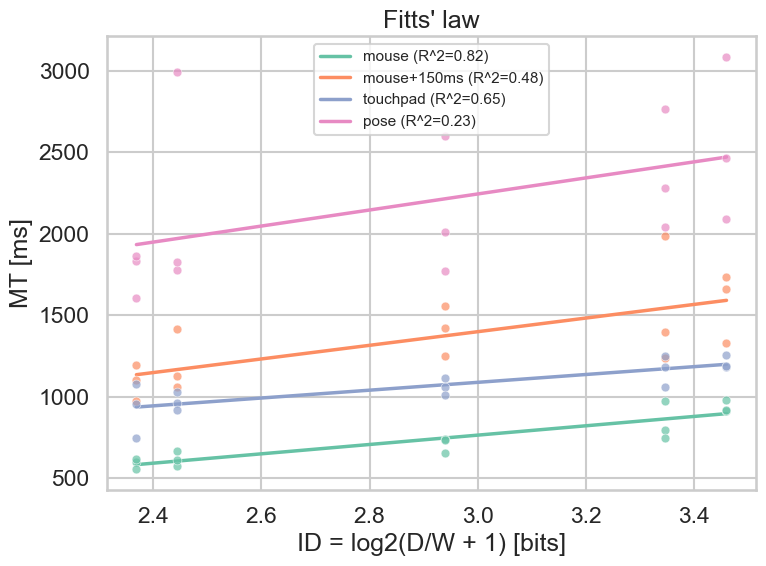

In [9]:
# movement time vs index of difficulty, with a linear fit per technique
fcond = taps.groupby(["tech", "pid", "target_w", "target_d", "difficulty"])["mt_ms"].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 6))
xs = np.linspace(fcond.difficulty.min(), fcond.difficulty.max(), 50)
for t in TECHNIQUES:
    gg = fcond[fcond.tech == t]
    line = stats.linregress(gg.difficulty, gg.mt_ms)  # linear regression to get slope, intercept, and R^2
    ax.scatter(gg.difficulty, gg.mt_ms, color=COLOR[t], s=40, alpha=0.7, edgecolor="white", lw=0.5, zorder=3)
    ax.plot(xs, line.intercept + line.slope * xs, color=COLOR[t], lw=2.5, label=f"{t} (R^2={line.rvalue**2:.2f})")
ax.set(xlabel="ID = log2(D/W + 1) [bits]", ylabel="MT [ms]", title="Fitts' law")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The mouse fits Fitts' law best (R²=0.82), while pose fits worst (R²=0.23).

## Throughput

Effective throughput in bits/s: `We = 4.133·SDx`, `IDe = log2(Ae/We + 1)`, `TP = IDe/MT`, taken per sequence then averaged ([method](https://www.yorku.ca/mack/hhci2018.html), [Soukoreff & MacKenzie 2004](https://www.yorku.ca/mack/ijhcs2004.pdf)).

In [10]:
keys = ["tech", "pid", "latency_ms", "target_w", "target_d", "iteration"]

d = fitts.sort_values(keys + ["step"]).copy()
d[["sx", "sy"]] = d.groupby(keys, sort=False)[["target_x", "target_y"]].shift()
d = d[d.step > 0].dropna(subset=["sx", "sy"])

theta = np.arctan2(d.target_y - d.sy, d.target_x - d.sx)
ex, ey = d.click_x - d.target_x, d.click_y - d.target_y
d["dx"] = ex * np.cos(theta) + ey * np.sin(theta)  # along-axis error
d["dy"] = ey * np.cos(theta) - ex * np.sin(theta)  # cross-axis error
d["amp"] = np.hypot(d.target_x - d.sx, d.target_y - d.sy)

# one row per sequence (ring of taps), then IDe/TP
hits = d[d.success == 1]
seq = (hits.groupby(keys)
           .agg(SDx=("dx", "std"), A=("amp", "mean"), off=("dx", "mean"), MT=("mt_ms", "mean"))
           .reset_index())

seq["Ae"]  = seq.A + seq.off  # effective amplitude
seq["IDe"] = np.log2(seq.Ae / (4.133 * seq.SDx) + 1)  # We = 4.133 * SDx
seq["TP"]  = seq.IDe / (seq.MT / 1000)  # throughput = IDe / MT [bits/s]
seq = seq.replace([np.inf, -np.inf], np.nan).dropna(subset=["TP"])


fitts_pid = seq.groupby(["tech", "pid"])["TP"].mean().reset_index()
fitts_tp = fitts_pid.groupby("tech")["TP"].agg(TP="mean", CI=ci95).reindex(TECHNIQUES).reset_index()
fitts_tp

,tech,TP,CI
0,mouse,4.556826,0.485406
1,mouse+150ms,2.345753,0.987646
2,touchpad,3.162878,0.452987
3,pose,1.282709,0.516419


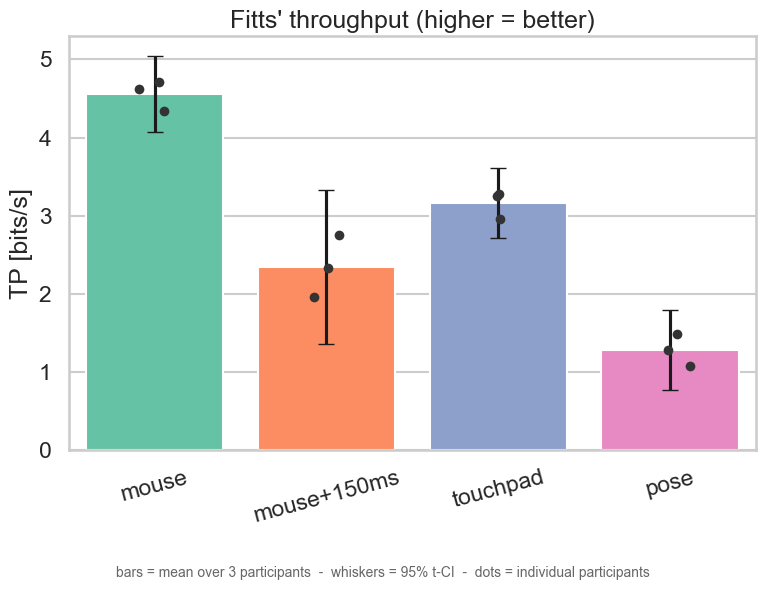

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(fitts_tp.tech, fitts_tp.TP, yerr=fitts_tp.CI, capsize=6, color=[COLOR[t] for t in TECHNIQUES])
sns.stripplot(data=fitts_pid, x="tech", y="TP", order=TECHNIQUES, color="0.2", size=7, jitter=0.12, ax=ax)
ax.set(xlabel="", ylabel="TP [bits/s]", title="Fitts' throughput (higher = better)")
ax.tick_params(axis="x", rotation=15)
fig.text(0.5, 0.01, "bars = mean over 3 participants  -  whiskers = 95% t-CI  -  dots = individual participants",
         ha="center", fontsize=10, color="0.4")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [12]:
# Fitts throughput per participant (the dots behind the bars)
fitts_pid.pivot(index="pid", columns="tech", values="TP").reindex(columns=TECHNIQUES).round(1)

tech,mouse,mouse+150ms,touchpad,pose
pid,,,,
1,4.7,2.0,3.3,1.3
2,4.6,2.7,3.0,1.1
3,4.3,2.3,3.3,1.5


Mouse (4.6) > touchpad (3.2) > mouse+150 ms (2.4) > pose (1.3) bits/s. The touchpad beats the lagged mouse.

## Accuracy

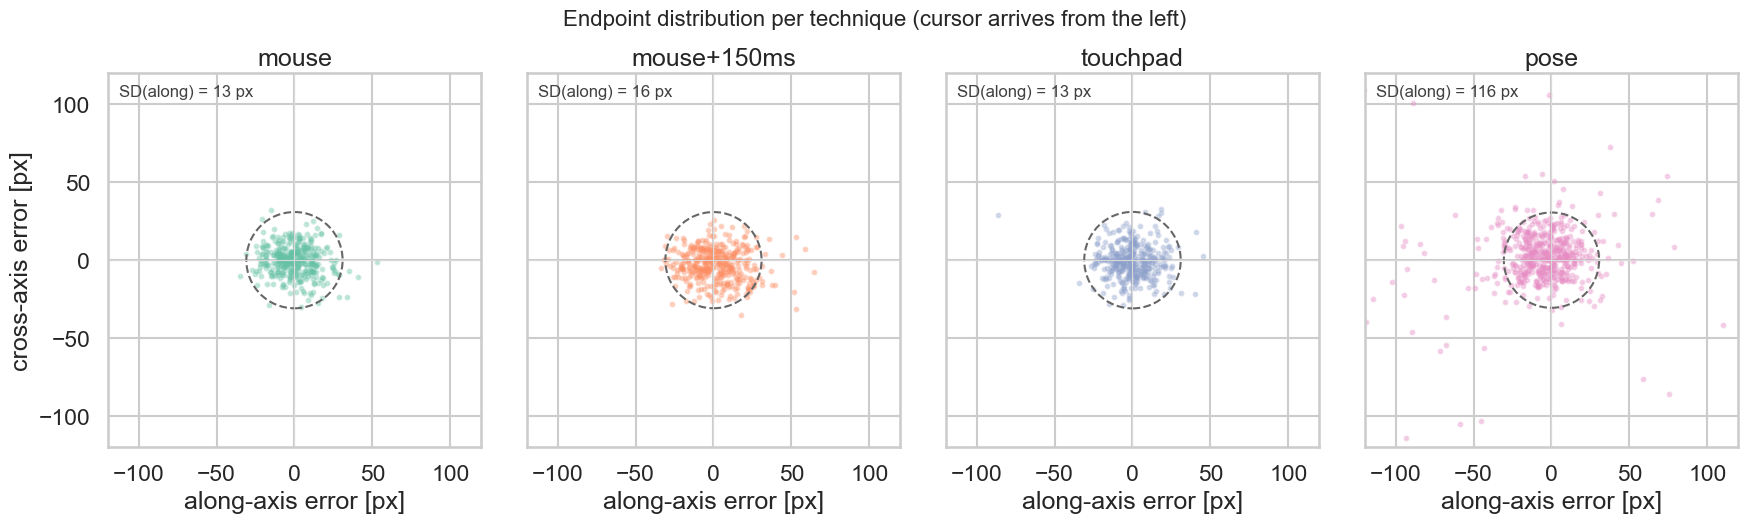

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
for ax, t in zip(axs, TECHNIQUES):
    s = d[d.tech == t]
    ax.scatter(s.dx, s.dy, s=8, alpha=0.3, color=COLOR[t])
    r = (fitts[fitts.tech == t].target_w / 2).mean()
    ax.add_patch(plt.Circle((0, 0), r, fill=False, color="0.4", lw=1.5, ls="--")) # target W
    ax.axhline(0, color="0.85", lw=0.8); ax.axvline(0, color="0.85", lw=0.8)
    ax.set_title(t); ax.set_aspect("equal")
    ax.set_xlim(-120, 120); ax.set_ylim(-120, 120)
    ax.set_xlabel("along-axis error [px]")
    ax.text(0.03, 0.97, f"SD(along) = {s.dx.std():.0f} px", transform=ax.transAxes,
            va="top", ha="left", fontsize=12, color="0.25")
axs[0].set_ylabel("cross-axis error [px]")
fig.suptitle("Endpoint distribution per technique (cursor arrives from the left)", fontsize=16)
plt.tight_layout()
plt.show()

Mouse, touchpad and lagged mouse all land tightly (SD 13-16 px). Pose is ~9 times worse (SD ≈ 116 px) with clicks well outside the target.

## Effect of 150 ms lag

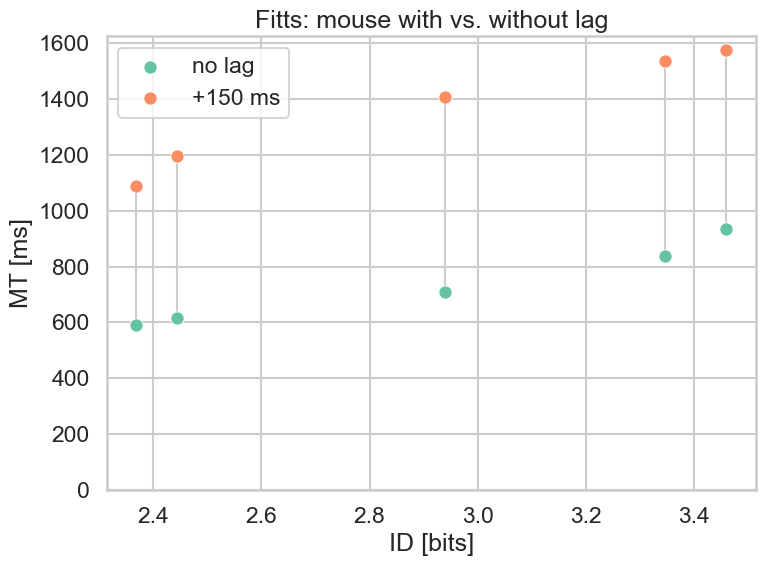

Mouse Tapping was 85% slower with 150 ms of lag.


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
fpair = (taps[taps.technique == "mouse"].groupby(["target_w", "target_d", "latency_ms"])["mt_ms"]
         .mean().unstack("latency_ms").dropna())
fdiff = np.log2(fpair.index.get_level_values("target_d") / fpair.index.get_level_values("target_w") + 1).to_numpy()
ax.scatter(fdiff, fpair[0], color=COLOR["mouse"], s=90, edgecolor="white", lw=0.6, zorder=3, label="no lag")
ax.scatter(fdiff, fpair[150], color=COLOR["mouse+150ms"], s=90, edgecolor="white", lw=0.6, zorder=3, label="+150 ms")
ax.vlines(fdiff, fpair[0], fpair[150], color="0.8", lw=1.5, zorder=1)
ax.set(xlabel="ID [bits]", ylabel="MT [ms]", title="Fitts: mouse with vs. without lag", ylim=(0, None))
ax.legend()
plt.tight_layout()
plt.show()

print("Mouse Tapping was %.0f%% slower with 150 ms of lag." % ((fpair[150].mean() / fpair[0].mean() - 1) * 100))

# Steering Law

## Speed

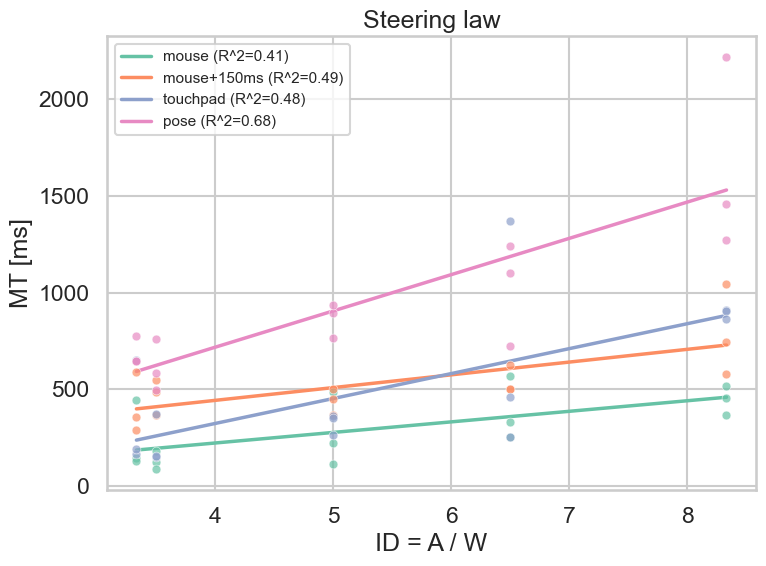

In [15]:
# traversal time vs steering difficulty (ID = A / W), with a linear fit per technique
scond = (steer.groupby(["tech", "pid", "tunnel_w", "tunnel_a", "difficulty"])["duration_ms"]
              .mean().reset_index())
fig, ax = plt.subplots(figsize=(8, 6))
xs = np.linspace(scond.difficulty.min(), scond.difficulty.max(), 50)
for t in TECHNIQUES:
    gg = scond[scond.tech == t]
    line = stats.linregress(gg.difficulty, gg.duration_ms)
    ax.scatter(gg.difficulty, gg.duration_ms, color=COLOR[t], s=40, alpha=0.7, edgecolor="white", lw=0.5, zorder=3)
    ax.plot(xs, line.intercept + line.slope * xs, color=COLOR[t], lw=2.5, label=f"{t} (R^2={line.rvalue**2:.2f})")
ax.set(xlabel="ID = A / W", ylabel="MT [ms]", title="Steering law")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Traversal time rises with ID. Surprisingly, Pose fits the steering law (R²=0.68) far better than it fit Fitts' and the other Steering conditions.

## Throughput

Steering throughput is `ID/MT` with `ID = A/W`, averaged per participant then across.

In [16]:
scond = (steer.groupby(["tech", "pid", "tunnel_w", "tunnel_a", "difficulty"])["duration_ms"]
         .mean().reset_index())
scond["TP"] = scond.difficulty / (scond.duration_ms / 1000.0)
steer_pid = scond.groupby(["tech", "pid"])["TP"].mean().reset_index()
steer_tp = (steer_pid.groupby("tech")["TP"].agg(TP="mean", CI=ci95).reindex(TECHNIQUES).reset_index())
steer_tp

,tech,TP,CI
0,mouse,22.327557,19.852031
1,mouse+150ms,10.266643,0.779636
2,touchpad,14.518343,13.429487
3,pose,5.726717,1.658389


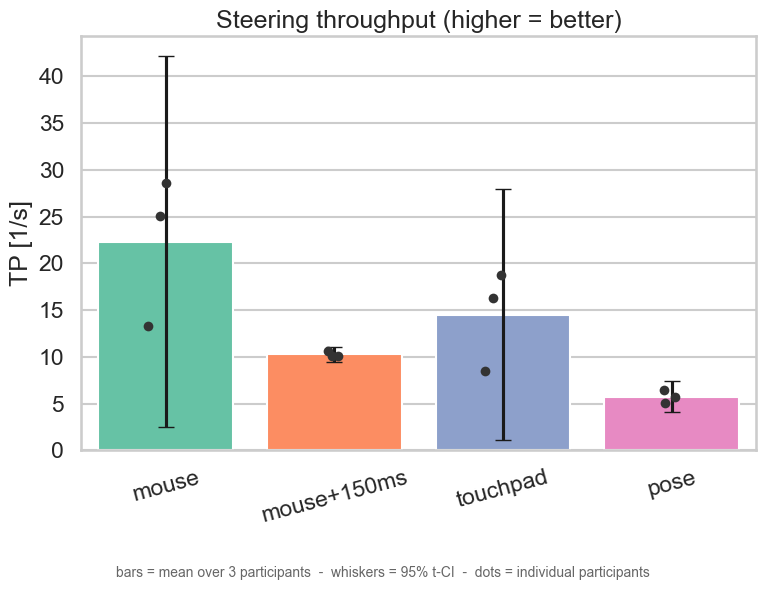

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(steer_tp.tech, steer_tp.TP, yerr=steer_tp.CI, capsize=6, color=[COLOR[t] for t in TECHNIQUES])
sns.stripplot(data=steer_pid, x="tech", y="TP", order=TECHNIQUES, color="0.2", size=7, jitter=0.12, ax=ax)
ax.set(xlabel="", ylabel="TP [1/s]", title="Steering throughput (higher = better)")
ax.tick_params(axis="x", rotation=15)
fig.text(0.5, 0.01, "bars = mean over 3 participants  -  whiskers = 95% t-CI  -  dots = individual participants",
         ha="center", fontsize=10, color="0.4")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [18]:
# steering throughput per participant (the dots behind the bars)
steer_pid.pivot(index="pid", columns="tech", values="TP").reindex(columns=TECHNIQUES).round(1)

tech,mouse,mouse+150ms,touchpad,pose
pid,,,,
1,28.6,10.1,8.4,5.1
2,25.0,10.6,16.3,5.7
3,13.3,10.1,18.8,6.4


Mouse (~22) > touchpad (~15) > mouse+150 ms (~10) > pose (~6) units/s. The mouse's error bar is huge though — one of the three was about half as fast as the other two — so lean on the ordering, not the exact mouse value.

## Accuracy

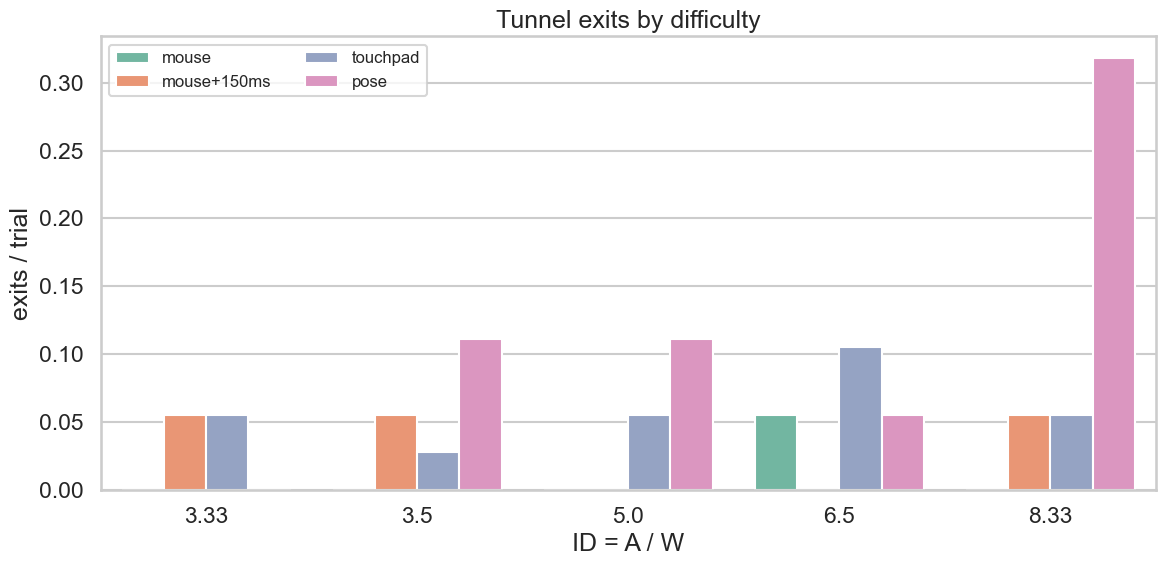

In [19]:
# steering tunnel exits per trial, by difficulty
order = sorted(steer.difficulty_lbl.unique(), key=float)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=steer, x="difficulty_lbl", y="violations", order=order, hue="tech",
            hue_order=TECHNIQUES, palette=COLOR, errorbar=None, ax=ax)
ax.set(xlabel="ID = A / W", ylabel="exits / trial", title="Tunnel exits by difficulty")
ax.legend(title="", fontsize=12, ncol=2)
plt.tight_layout(); plt.show()

In [20]:
# tunnel exits per trial: each difficulty, plus the mean averaged over IDs
exits = (steer.groupby(["tech", "difficulty_lbl"])["violations"].mean()
              .unstack("difficulty_lbl").reindex(TECHNIQUES))
exits = exits[sorted(exits.columns, key=float)]
exits["mean"] = exits.mean(axis=1)
exits.round(2)

difficulty_lbl,3.33,3.5,5.0,6.5,8.33,mean
tech,,,,,,
mouse,0.00,0.00,0.00,0.06,0.00,0.01
mouse+150ms,0.06,0.06,0.00,0.00,0.06,0.03
touchpad,0.06,0.03,0.06,0.11,0.06,0.06
pose,0.00,0.11,0.11,0.06,0.32,0.12


Wall exits rise with difficulty. The mouse barely leaves the tunnel (~0.01/run) and pose is worst (~0.16/run). Lag adds little, so steering handles latency better than the touchpad.

## Effect of 150 ms lag

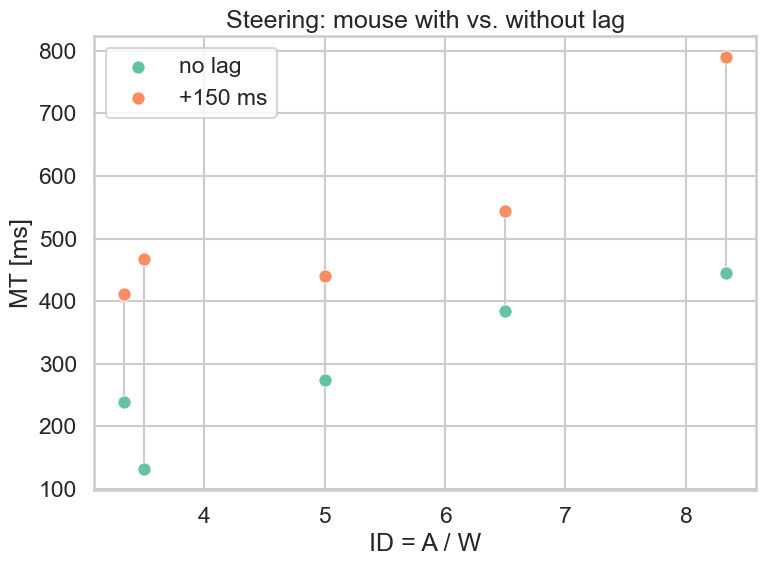

Mouse Steering was 80% slower with 150 ms of lag.


In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
spair = (steer[steer.technique == "mouse"].groupby(["tunnel_w", "tunnel_a", "latency_ms"])["duration_ms"]
         .mean().unstack("latency_ms").dropna())
sdiff = (spair.index.get_level_values("tunnel_a") / spair.index.get_level_values("tunnel_w")).to_numpy()
ax.vlines(sdiff, spair[0], spair[150], color="0.8", lw=1.5, zorder=1)
ax.scatter(sdiff, spair[0],   color=COLOR["mouse"],       s=90, edgecolor="white", lw=0.6, zorder=3, label="no lag")
ax.scatter(sdiff, spair[150], color=COLOR["mouse+150ms"], s=90, edgecolor="white", lw=0.6, zorder=3, label="+150 ms")
ax.set(xlabel="ID = A / W", ylabel="MT [ms]", title="Steering: mouse with vs. without lag"); ax.legend()
plt.tight_layout()
plt.show()

print("Mouse Steering was %.0f%% slower with 150 ms of lag." % ((spair[150].mean() / spair[0].mean() - 1) * 100))

# Summary

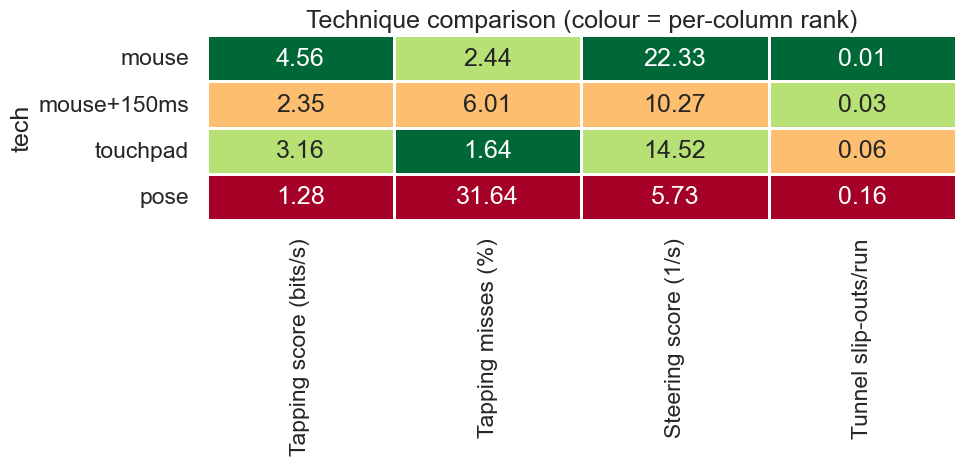

,Tapping score (bits/s),Tapping misses (%),Steering score (1/s),Tunnel slip-outs/run
tech,,,,
mouse,4.56,2.44,22.33,0.01
mouse+150ms,2.35,6.01,10.27,0.03
touchpad,3.16,1.64,14.52,0.06
pose,1.28,31.64,5.73,0.16


In [22]:
err_overall  = (fitts[fitts.step > 0].assign(missed=lambda x: 1 - x.success)
                .groupby("tech")["missed"].mean() * 100)
viol_overall = steer.groupby("tech")["violations"].mean()

summary = pd.DataFrame({
    "Tapping score (bits/s)": fitts_tp.set_index("tech")["TP"],
    "Tapping misses (%)":     err_overall,
    "Steering score (1/s)":   steer_tp.set_index("tech")["TP"],
    "Tunnel slip-outs/run":   viol_overall,
}).reindex(TECHNIQUES).round(2)

higher_is_better = {"Tapping score (bits/s)": True, "Tapping misses (%)": False,
                    "Steering score (1/s)": True, "Tunnel slip-outs/run": False}
n = len(summary); shade = summary.copy()
for col, hi in higher_is_better.items():
    rank = summary[col].rank(ascending=not hi, method="min")   # 1 = best
    shade[col] = (n - rank) / (n - 1)                          # 1 = best (green), 0 = worst (red)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(shade, annot=summary.values, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar=False, linewidths=1, linecolor="white", ax=ax)
ax.set(title="Technique comparison (colour = per-column rank)")
plt.tight_layout(); plt.show()

summary

Mouse is best on three of the four measures, the touchpad only on tapping accuracy, pose is worst on everything. The lagged mouse lands mid-pack.